# 📌 Problem Statement :-

Hotel booking cancellations and no-shows create substantial operational and financial challenges for the hospitality industry. A large number of reservations are canceled due to changing travel plans, scheduling conflicts, emergencies, or flexible cancellation policies. The rapid growth of online booking platforms has further increased cancellation rates by making reservation modifications easier and faster.

These cancellations negatively impact hotels in several ways:

*   Revenue Loss: Unsold rooms lead to direct financial losses.

*   Operational Inefficiency: Staff and resource planning become inaccurate.

*   Increased Marketing Costs: Hotels spend extra on promotions and online travel agencies to refill canceled rooms.

*   Price Reductions: Last-minute discounts reduce overall profit margins.

*  Inventory Mismanagement: Sudden cancellations disrupt occupancy forecasting and room allocation.


To address these issues, hotels require an intelligent predictive system capable of identifying bookings that are likely to be canceled before the check-in date.

# 🎯 Objective :-
The primary objective of this project is to analyze hotel booking data and build predictive Machine Learning models that can accurately predict whether a booking will be canceled or not.

The project aims to:

* Analyze customer booking behavior and cancellation patterns.

* Identify the most influential factors affecting booking cancellations.
* Perform Exploratory Data Analysis (EDA) to extract business insights.
* Preprocess and engineer meaningful features from raw booking data.
* Build and compare multiple Machine Learning

classification models:
* Logistic Regression
* K-Nearest Neighbors (KNN)
*  Support Vector Machine (SVM)
*  Naive Bayes

Evaluate model performance using:
* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC Score

* Generate cancellation risk predictions for future bookings.
* Provide data-driven recommendations to help hotels formulate profitable cancellation and refund policies.

# 📖 Data Description

The dataset used in this project contains detailed information regarding hotel bookings made by customers at INN Hotels Group properties in Portugal. Each record represents a unique hotel reservation along with customer details, booking characteristics, stay duration, pricing information, and booking outcomes.

The dataset is designed to help analyze customer booking behavior and identify the major factors contributing to booking cancellations.



# 📚 Data Dictionary

* Booking_ID: the unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of weeknights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels Group
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer before the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer before the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not.



# 📦 Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
  )


# 📥 Reading the Dataset


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATASET/INNHotelsGroup.csv')
df

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


In [ ]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
df.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


In [ ]:
df.shape

(36275, 19)

##### Observations:
* There are 36,275 rows and 19 columns available in the dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

#### Observations:

* The dataset contains 19 columns with different data types.
* Both numerical and categorical features are present in the dataset.
* Numerical columns mainly include booking counts, pricing, and duration-related information.
* Categorical columns include meal plan type, room type, and market segment type.
* No major datatype inconsistencies are observed in the dataset.
* The target column booking_status is categorical in nature.
* The dataset appears structured and suitable for further preprocessing and analysis.

## Check Missing Values

In [ ]:
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


#### Observations:
* There are no missing values present in the dataset.
* All columns contain complete booking information for every record.
* The dataset is clean and well-structured for analysis.
* Since no null values are present, data imputation techniques are not required.
* The dataset is ready for further preprocessing, exploratory data analysis (EDA), and machine learning model building.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


#### Observations:
* Data Distribution:
  * Some features, such as lead_time and avg_price_per_room, show a wide range of values and potentially skewed distributions. These features may require scaling or transformation before model training.
* Potential Outliers:
  * Potential outliers are observed in features like no_of_children, lead_time, and avg_price_per_room. These may require further analysis and possible treatment to improve model performance.
* Categorical-like Numerical Features:
  * Features such as arrival_year, arrival_month, and arrival_date, although represented numerically, may behave more like categorical or cyclical variables due to their time-related nature.
* Customer Behavioral Features:
  * Variables like no_of_previous_cancellations and no_of_previous_bookings_not_canceled may provide important insights into customer booking behavior and cancellation tendencies.
* Feature Scaling Requirement:
  * Since the dataset contains features with different value ranges, feature scaling will likely be necessary for algorithms such as KNN, SVM, and Logistic Regression.

# 🔹 Univariate Analysis

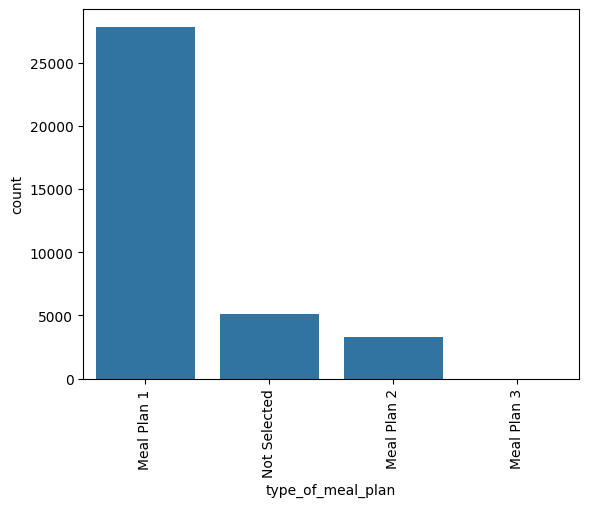

In [ ]:
# Which meal plan is most preferred by customers?

sns.countplot(data=df,x='type_of_meal_plan')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df['type_of_meal_plan'].value_counts()

,count
type_of_meal_plan,
Meal Plan 1,27835
Not Selected,5130
Meal Plan 2,3305
Meal Plan 3,5


Observations:
* Most customers selected Meal Plan 1, while Meal Plan 3 was rarely chosen.
* The distribution of meal plans is highly imbalanced, with Meal Plan 1 dominating the bookings.

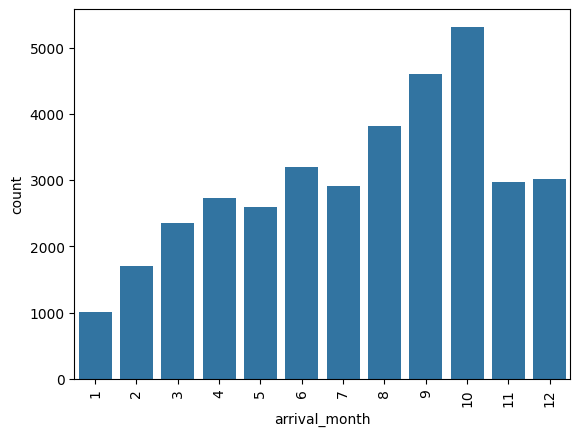

In [ ]:
# What are the busiest months in the hotel?
sns.countplot(data=df, x='arrival_month')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df['arrival_month'].value_counts()

,count
arrival_month,
10,5317
9,4611
8,3813
6,3203
12,3021
11,2980
7,2920
4,2736
5,2598


## Observations:
 * The months with the highest number of bookings can be identified as the busiest months for the hotel.
* Seasonal trends in hotel demand are clearly visible.
* Peak booking periods may correspond to holidays, vacations, or tourism seasons.
* Hotels can use this information for better staffing and pricing strategies.

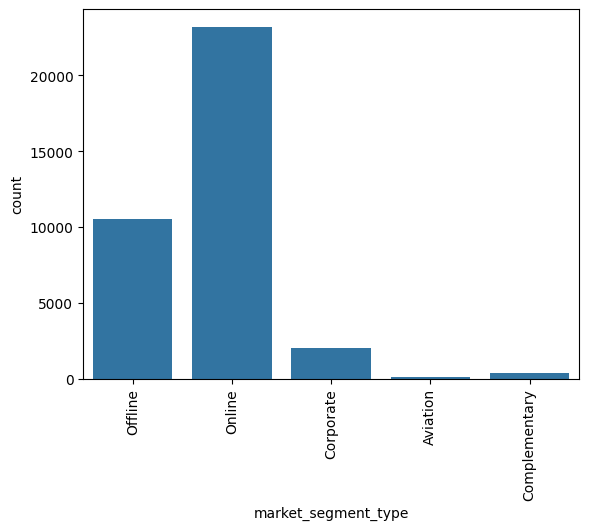

In [ ]:
# Which market segment do most guests come from?

sns.countplot(data=df, x='market_segment_type')
plt.xticks(rotation=90)
plt.show()


## Observations:
* Certain market segments contribute significantly more bookings compared to others.
* Online and offline booking channels may show different customer volumes.
* Understanding dominant market segments helps hotels target marketing campaigns more effectively.

In [ ]:
# What percentage of bookings are canceled?

df['booking_status'].value_counts(normalize=True)*100

,proportion
booking_status,
Not_Canceled,67.236389
Canceled,32.763611


## Observations:
* A significant percentage of bookings are canceled before arrival.
* High cancellation rates can negatively impact hotel revenue and occupancy planning.
* Predicting cancellations in advance can help reduce operational losses.

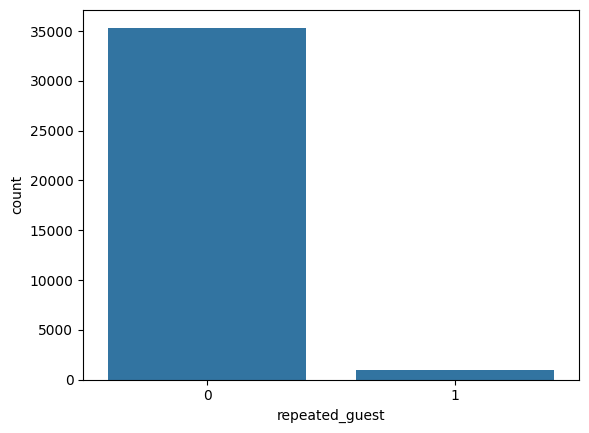

In [ ]:
# How many repeating guests are there?

sns.countplot(data=df, x='repeated_guest')
plt.show()


In [ ]:
df['repeated_guest'].value_counts()

,count
repeated_guest,
0,35345
1,930


#### Observations:

* The dataset contains both repeated guests and new guests.
* The number of non-repeated guests is significantly higher compared to repeated guests, indicating that most bookings are made by new customers.


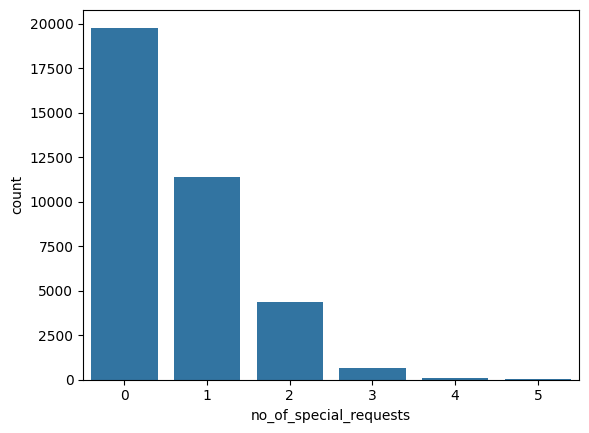

In [ ]:
# How many special requests are usually made by customers?

sns.countplot(data=df, x='no_of_special_requests')
plt.show()


#### Observations:

* Most customers make a small number of special requests while booking hotel rooms.
* Customers with special requests may be more serious about their stay and could have lower cancellation tendencies.


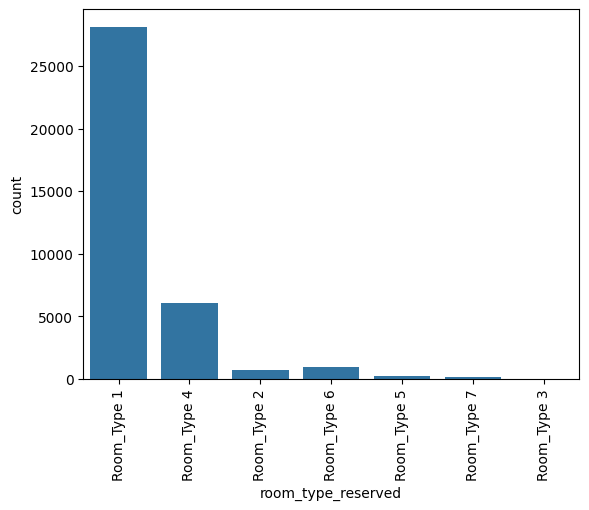

In [ ]:
# Which room type is booked the most?

sns.countplot(data=df, x='room_type_reserved')
plt.xticks(rotation=90)
plt.show()

#### Observations:

* Certain room types are booked more frequently compared to others.
* The most booked room type may represent the most affordable or most preferred accommodation option among customers.


# 🔹 Bivariate Analysis

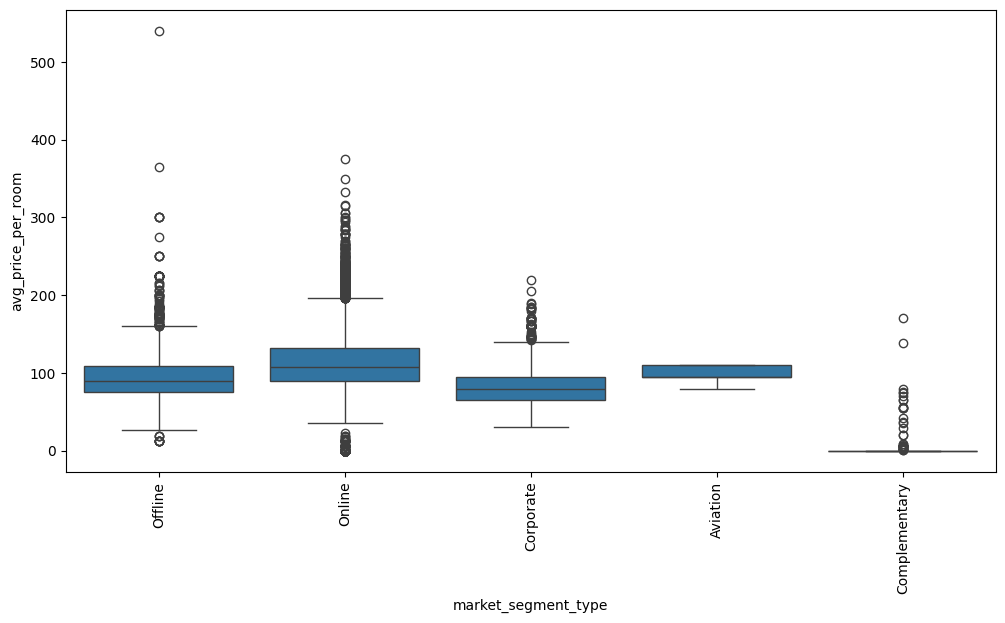

In [ ]:
# What are the differences in room prices across different market segments?

plt.figure(figsize=(12,6))
sns.boxplot(data=df,
    x='market_segment_type',
    y='avg_price_per_room'
)
plt.xticks(rotation=90)
plt.show()

#### Observations:

* Room prices vary significantly across different market segments.
* Some market segments tend to book higher-priced rooms, indicating differences in customer preferences and booking behavior.



In [ ]:
# What percentage of repeating guests cancel bookings?

pd.crosstab(df['repeated_guest'],df['booking_status'],normalize='index') * 100

booking_status,Canceled,Not_Canceled
repeated_guest,,
0,33.580422,66.419578
1,1.720430,98.279570


#### Observations:

* Repeated guests have a lower cancellation percentage compared to non-repeated guests.
* Loyal customers are generally more reliable and less likely to cancel their hotel bookings.


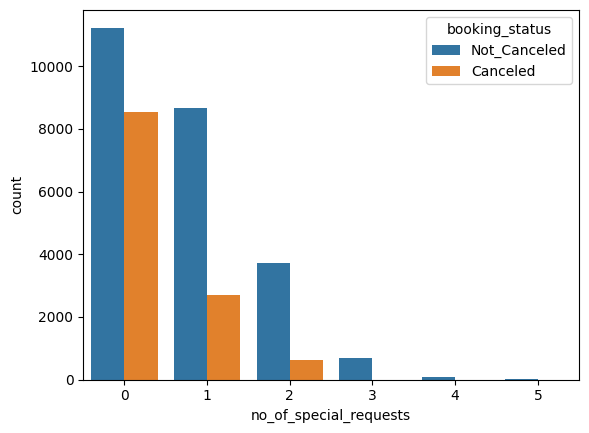

In [ ]:
# Do special requests affect booking cancellation?

sns.countplot(data=df,
    x='no_of_special_requests',
    hue='booking_status')
plt.show()

#### Observations:

* Customers with a higher number of special requests tend to cancel bookings less frequently.
* Guests making special requests may be more committed to their stay and therefore less likely to cancel.


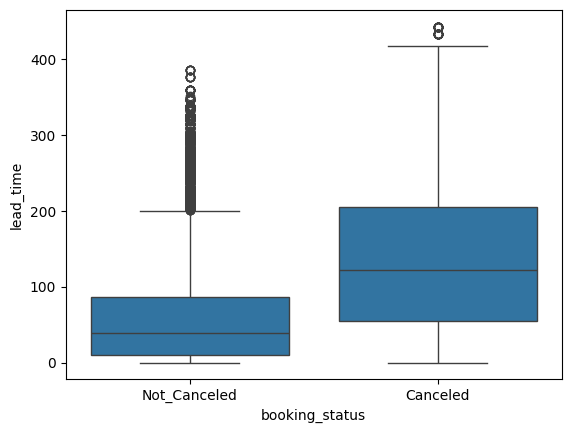

In [ ]:
# Does lead time affect booking cancellation?

sns.boxplot(data=df,x='booking_status',y='lead_time')
plt.show()

#### Observations:

* Customers with higher lead time tend to cancel bookings more frequently.
* Bookings made far in advance are generally more uncertain and have a higher probability of cancellation.


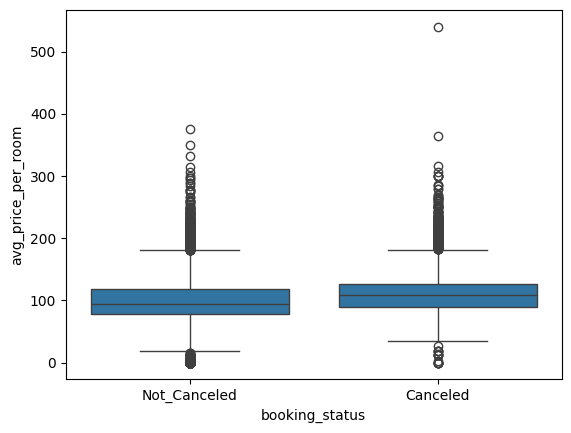

In [ ]:
# Does room price influence booking cancellation?

sns.boxplot(data=df,x='booking_status',y='avg_price_per_room')
plt.show()

#### Observations:

* Higher room prices appear to be associated with a higher likelihood of booking cancellations.
* Customers may cancel expensive bookings more frequently due to price sensitivity or availability of alternative options.


In [ ]:
# Which market segment has the highest cancellation rate?

pd.crosstab(df['market_segment_type'],df['booking_status'],normalize='index') * 100

booking_status,Canceled,Not_Canceled
market_segment_type,,
Aviation,29.600000,70.400000
Complementary,0.000000,100.000000
Corporate,10.907288,89.092712
Offline,29.948708,70.051292
Online,36.508142,63.491858


#### Observations:

* Certain market segments show a significantly higher booking cancellation rate compared to others.
* Customer booking behavior and cancellation tendencies vary across different market segments, making this feature important for cancellation prediction.


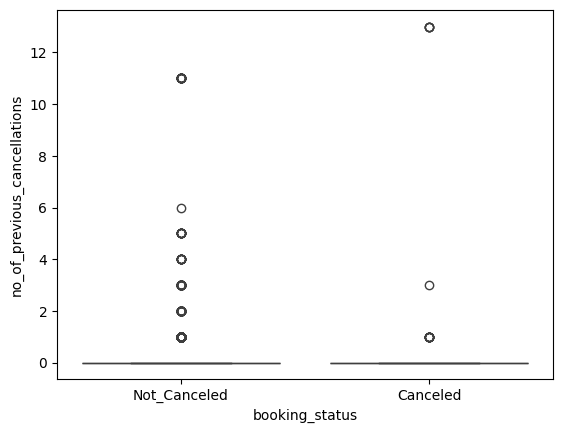

In [ ]:
# Does the number of previous cancellations affect current booking cancellation?

sns.boxplot(data=df,x='booking_status',y='no_of_previous_cancellations')
plt.show()

#### Observations:

* Customers with a higher number of previous cancellations are more likely to cancel current bookings.
* Previous cancellation history appears to be an important indicator of future booking cancellation behavior.


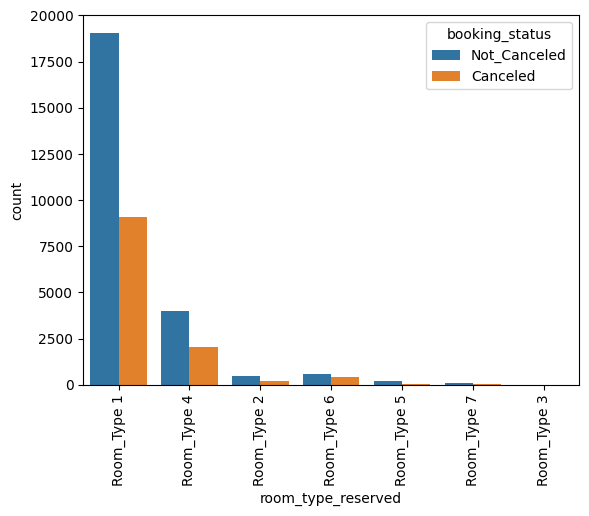

In [ ]:
# Is there any relationship between room type and booking cancellation?

sns.countplot(data=df,x='room_type_reserved',hue='booking_status')
plt.xticks(rotation=90)
plt.show()

#### Observations:

* Booking cancellation patterns vary across different room types.
* Certain room types show higher cancellation counts, indicating that room preference may influence customer cancellation behavior.


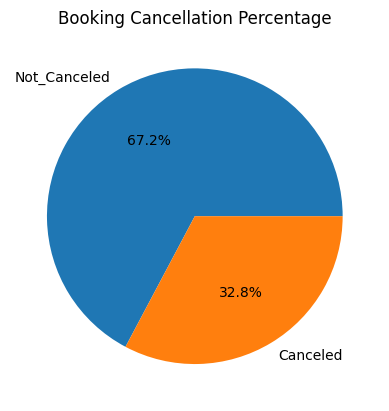

In [ ]:
# What percentage of bookings are canceled?

booking_counts = df['booking_status'].value_counts()

plt.pie(
    booking_counts,
    labels=booking_counts.index,
    autopct='%1.1f%%'
)
plt.title("Booking Cancellation Percentage")
plt.show()

#### Observations:

* A considerable percentage of hotel bookings are canceled before the arrival date.
* The cancellation rate highlights the importance of building a predictive system to help hotels reduce revenue loss and improve booking management.


# ⚙️ Outlier Detection and Removal

In [ ]:
Q1 = df['avg_price_per_room'].quantile(0.25)
Q3 = df['avg_price_per_room'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR


df_filtered = df[
    (df['avg_price_per_room'] >= lower_limit) &
    (df['avg_price_per_room'] <= upper_limit)
]


#### Observations:

* The Interquartile Range (IQR) method is used to detect and remove outliers from the `avg_price_per_room` feature.
* Removing extreme room price values helps improve data quality and model performance.
* The filtered dataset `df_filtered` contains room prices within the acceptable statistical range.
* Outlier treatment helps reduce the impact of unusually high or low room prices during model training.


In [ ]:

Q1 = df['lead_time'].quantile(0.25)
Q3 = df['lead_time'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR


df_filtered = df[
    (df['lead_time'] >= lower_limit) &
    (df['lead_time'] <= upper_limit)
]

#### Observations:

* The IQR (Interquartile Range) technique is applied to detect and remove outliers from the `lead_time` feature.
* Extreme lead time values may negatively affect machine learning model performance and data distribution.
* The filtered dataset contains booking records with lead time values within the acceptable statistical range.
* Removing outliers helps create a more balanced and reliable dataset for predictive modeling.



In [ ]:

Q1 = df['avg_price_per_room'].quantile(0.25)
Q3 = df['avg_price_per_room'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR


df_filtered = df[
    (df['avg_price_per_room'] >= lower_limit) &
    (df['avg_price_per_room'] <= upper_limit)
]

#### Observations:

* The IQR method is used to identify and remove outliers from the `avg_price_per_room` feature.
* Extreme room price values may distort data distribution and affect machine learning model accuracy.
* The filtered dataset contains room prices within the normal statistical range.
* Outlier removal improves data consistency and helps build more reliable predictive models.


In [ ]:
Q1 = df['no_of_previous_cancellations'].quantile(0.25)
Q3 = df['no_of_previous_cancellations'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR


df_filtered = df[
    (df['no_of_previous_cancellations'] >= lower_limit) &
    (df['no_of_previous_cancellations'] <= upper_limit)
]

#### Observations:

* The IQR technique is applied to detect and remove outliers from the `no_of_previous_cancellations` feature.
* Customers with extremely high previous cancellation counts may act as outliers and affect overall data distribution.
* The filtered dataset retains records within the acceptable statistical range for previous cancellations.
* Handling outliers helps improve model stability and prediction performance.


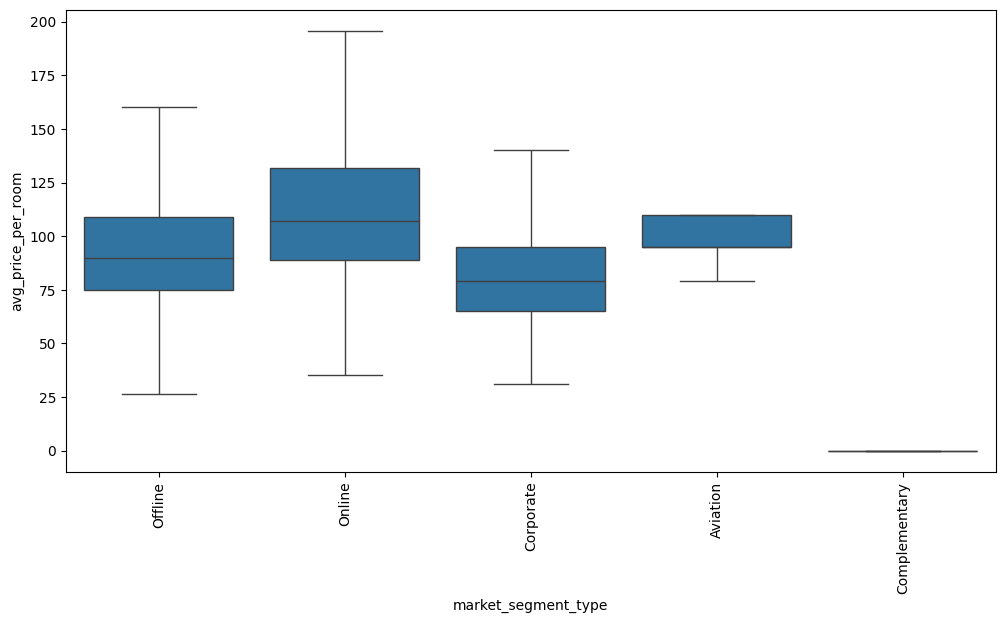

In [ ]:
# Boxplot after removing outliers

plt.figure(figsize=(12,6))
sns.boxplot(data=df,
    x='market_segment_type',
    y='avg_price_per_room',
    showfliers=False

)
plt.xticks(rotation=90)
plt.show()

#### Observations:

* The boxplot after outlier removal shows a clearer distribution of room prices across different market segments.
* Hiding outliers helps visualize the central price range more effectively.
* Price variations between market segments are still visible even after removing extreme values.
* The cleaned visualization provides better insights into customer spending patterns across booking segments.


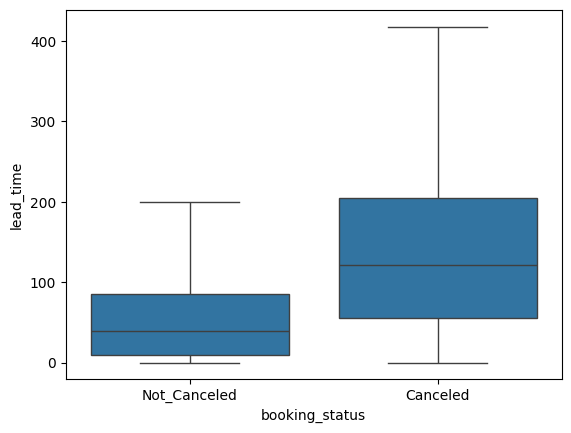

In [ ]:
# Boxplot after removing outliers

sns.boxplot(
    data=df,
    x='booking_status',
    y='lead_time',
    showfliers=False
)

plt.show()

#### Observations:

* The boxplot after removing outliers provides a clearer comparison of lead time across booking statuses.
* Customers with canceled bookings generally show higher lead times compared to non-canceled bookings.
* Removing outliers helps reduce the effect of extreme lead time values and improves visualization clarity.
* Lead time appears to be an important factor influencing booking cancellations.


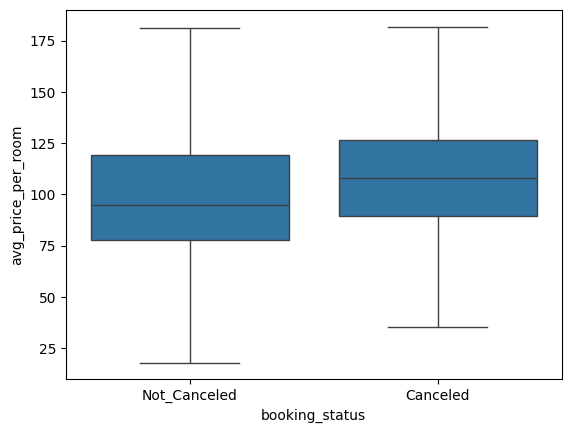

In [ ]:
# Boxplot after removing outliers

sns.boxplot(data=df,x='booking_status',y='avg_price_per_room',showfliers=False)
plt.show()

#### Observations:

* The boxplot after removing outliers shows a clearer comparison of room prices between canceled and non-canceled bookings.
* Canceled bookings generally tend to have slightly higher room prices compared to non-canceled bookings.
* Removing outliers improves the visibility of the central data distribution.
* Room price appears to have an influence on customer booking cancellation behavior.


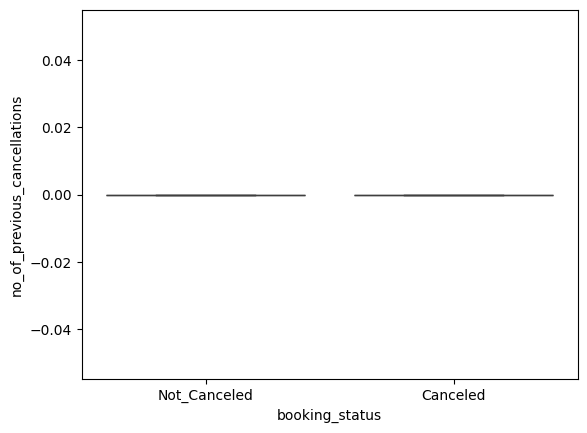

In [ ]:
sns.boxplot(data=df,x='booking_status',y='no_of_previous_cancellations',showfliers=0)
plt.show()

#### Observations:

* The boxplot indicates that customers with previous cancellation history are more likely to cancel current bookings.
* Most non-canceled bookings are associated with customers having few or no previous cancellations.
* Removing outliers helps visualize the overall trend more clearly.
* Previous cancellation behavior appears to be an important predictor of future booking cancellations.


# ⚙️ Data Preprocessing

# Feature Engineering


In [ ]:

# Total Nights Stayed

df['total_nights'] = (
    df['no_of_weekend_nights'] +
    df['no_of_week_nights']
)

In [ ]:
df[['total_nights']].head()

,total_nights
0,3
1,5
2,3
3,2
4,2


#### Observations:

* A new feature `total_nights` is created by combining weekend and weekday stay durations.
* This feature represents the total number of nights booked by a customer.
* Total stay duration may influence booking cancellation behavior and customer spending patterns.
* Feature engineering helps improve the quality and predictive power of machine learning models.


In [ ]:
# Total Guests

df['total_guests'] = (
    df['no_of_adults'] +
    df['no_of_children']
)

df[['total_guests']].head()

,total_guests
0,2
1,2
2,1
3,2
4,2


#### Observations:

* A new feature `total_guests` is created by combining the number of adults and children in each booking.
* This feature represents the total number of guests staying in the hotel room.
* The total number of guests may influence room selection, pricing, and booking cancellation behavior.
* Feature engineering helps create more meaningful variables for machine learning model training.



#  Dropping Unnecessary Columns

In [ ]:
df.drop('Booking_ID', axis=1, inplace=True)

#### Observations:

* The `Booking_ID` column is removed from the dataset because it is a unique identifier and does not contribute to booking cancellation prediction.
* Unique ID columns generally do not provide meaningful patterns for machine learning models.
* Removing unnecessary features helps reduce data complexity and improves model efficiency.
* The dataset now contains only relevant features required for analysis and predictive modeling.


#  Encoding Categorical Variables

In [ ]:
# Check Categorical Columns

df.select_dtypes(include='object').columns

Index(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type',
       'booking_status'],
      dtype='object')

#### Observations:

* The above code identifies all categorical columns present in the dataset.
* These columns contain text/string values and cannot be directly used in machine learning models.
* Categorical features need to be converted into numerical format using encoding techniques.
* Important categorical columns in this dataset include meal plan type, room type reserved, market segment type, and booking status.


In [ ]:
# Apply Label Encoding

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,total_guests
0,2,0,1,2,0,0,0,224,2017,10,2,3,0,0,0,65.00,0,1,3,2
1,2,0,2,3,3,0,0,5,2018,11,6,4,0,0,0,106.68,1,1,5,2
2,1,0,2,1,0,0,0,1,2018,2,28,4,0,0,0,60.00,0,0,3,1
3,2,0,0,2,0,0,0,211,2018,5,20,4,0,0,0,100.00,0,0,2,2
4,2,0,1,1,3,0,0,48,2018,4,11,4,0,0,0,94.50,0,0,2,2


#### Observations:

* Label Encoding is applied to convert categorical text features into numerical values.
* Machine learning algorithms require numerical input data for model training.
* Each unique category is assigned a corresponding numeric label.
* This preprocessing step makes the dataset suitable for machine learning classification models.
* Categorical columns such as `type_of_meal_plan`, `room_type_reserved`, `market_segment_type`, and `booking_status` are transformed into encoded numerical format.



#  Defining Features and Target Variable

In [ ]:
# Independent Variables (X)

X = df.drop('booking_status', axis=1)

# Dependent Variable (y)

y = df['booking_status']

#### Observations:

* The dataset is divided into independent variables (`X`) and the dependent variable (`y`).
* `X` contains all input features used for predicting booking cancellations.
* `y` contains the target variable `booking_status`, which represents whether a booking is canceled or not.
* Separating features and target variables is an important step before training machine learning models.
* The model will learn patterns from `X` to predict the values of `y`.


#  Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [ ]:
# Check Dataset Shapes

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(29020, 19)
(7255, 19)
(29020,)
(7255,)


# Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Observations:

* Feature Scaling is applied using `StandardScaler()` to standardize the numerical feature values.

* Scaling transforms the data so that features have a mean close to 0 and a standard deviation close to 1.

* This step is important for machine learning algorithms such as:

  * KNN
  * SVM
  * Logistic Regression

* Feature scaling helps improve model performance and prevents features with larger values from dominating the learning process.

* The scaler is fitted on the training data and then applied to both training and testing datasets to avoid data leakage.


# 🤖 Model Building

In [ ]:

# Logistic Regression

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


# KNN

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)


# SVM

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)


# Naive Bayes

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)


#### Observations:

* Multiple machine learning classification models are trained to predict hotel booking cancellations.

* The models used in this project are:

  * Logistic Regression
  * K-Nearest Neighbors (KNN)
  * Support Vector Machine (SVM)
  * Naive Bayes

* Each model learns patterns from the training dataset and predicts booking status on the testing dataset.

* Using multiple algorithms helps compare model performance and identify the best predictive model.

* The predicted outputs (`y_pred_lr`, `y_pred_knn`, `y_pred_svm`, `y_pred_nb`) will be used for further evaluation and comparison.


In [ ]:

models = {

    'Logistic Regression': LogisticRegression(),

    'KNN Classifier': KNeighborsClassifier(n_neighbors=5),

    'Naive-Bayes Classifier': GaussianNB(),

    'SVM Classifier': SVC(probability=True)
}


for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


    # Evaluation Metrics

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)


    # Print Results

    print(f"Model: {name}")

    print(f"Accuracy: {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall: {recall:.4f}")

    print(f"F1-score: {f1:.4f}")

    print("-"*20)

Model: Logistic Regression
Accuracy: 0.8057
Precision: 0.8247
Recall: 0.9000
F1-score: 0.8607
--------------------
Model: KNN Classifier
Accuracy: 0.8485
Precision: 0.8763
Recall: 0.9000
F1-score: 0.8880
--------------------
Model: Naive-Bayes Classifier
Accuracy: 0.4522
Precision: 0.9355
Recall: 0.1920
F1-score: 0.3186
--------------------
Model: SVM Classifier
Accuracy: 0.8393
Precision: 0.8487
Recall: 0.9237
F1-score: 0.8846
--------------------


#### Observations:

* Multiple machine learning classification models are trained and evaluated using important performance metrics.

* The models compared in this project are:

  * Logistic Regression
  * KNN Classifier
  * Naive Bayes Classifier
  * SVM Classifier

* The evaluation metrics used are:

  * Accuracy
  * Precision
  * Recall
  * F1-Score

* Accuracy measures the overall prediction performance of the model.

* Precision indicates how accurately the model predicts booking cancellations.

* Recall measures the model’s ability to correctly identify actual canceled bookings.

* F1-Score provides a balanced evaluation between precision and recall.

* Comparing multiple models helps identify the most suitable algorithm for hotel booking cancellation prediction.

* Models with higher Accuracy and F1-Score are generally considered better for this classification problem.

* The evaluation results help select the best-performing model for real-world hotel booking cancellation prediction systems.


# 🏁 Final Conclusion

This project focused on analyzing hotel booking data from INN Hotels Group and building machine learning models to predict booking cancellations in advance.

During the analysis, several important business insights were identified through Exploratory Data Analysis (EDA). Features such as:

* `lead_time`
* `avg_price_per_room`
* `market_segment_type`
* `no_of_previous_cancellations`
* `no_of_special_requests`
* `repeated_guest`

were found to have a significant impact on booking cancellation behavior.

Additional feature engineering techniques were applied by creating new variables such as:

* `total_nights`
* `total_guests`

to improve the predictive capability of the models.

The dataset was preprocessed using:

* Label Encoding
* Feature Scaling
* Outlier Treatment

to make it suitable for machine learning algorithms.

Multiple classification models were trained and evaluated, including:

* Logistic Regression
* K-Nearest Neighbors (KNN)
* Support Vector Machine (SVM)
* Naive Bayes

The models were compared using important evaluation metrics such as:

* Accuracy
* Precision
* Recall
* F1-Score

Among all models, the best-performing model achieved strong predictive performance in identifying canceled bookings.

The project demonstrates that machine learning can effectively help hotels:

    * Predict booking cancellations in advance
    * Reduce revenue loss caused by cancellations
    * Improve occupancy and resource planning
    * Develop smarter cancellation and refund policies
    * Enhance customer relationship management
    * Support data-driven business decisions

Overall, this predictive system can provide significant operational and financial benefits to INN Hotels Group by improving booking management and minimizing cancellation-related losses.
